In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [7]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [10]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [11]:
mean_age=X_train['Age'].mean()
median_age=X['Age'].median()

mean_fare=X['Fare'].mean()
median_fare=X['Fare'].median()

In [12]:
X_train['median_Age']=X_train['Age'].fillna(median_age)
X_train['mean_Age']=X_train['Age'].fillna(mean_age)

X_train['median_Fare']=X_train['Fare'].fillna(median_fare)
X_train['mean_Fare']=X_train['Fare'].fillna(mean_fare)


In [13]:
X_train.sample(5)

,Age,Fare,Family,median_Age,mean_Age,median_Fare,mean_Fare
788,1.0,20.5750,3,1.0,1.0,20.5750,20.5750
641,24.0,69.3000,0,24.0,24.0,69.3000,69.3000
514,24.0,7.4958,0,24.0,24.0,7.4958,7.4958
515,47.0,34.0208,0,47.0,47.0,34.0208,34.0208
110,47.0,52.0000,0,47.0,47.0,52.0000,52.0000


In [14]:
print('original age variable variance',X_train['Age'].var())
print('After imputation age median variable variance',X_train['median_Age'].var())
print('original age mean variable variance',X_train['mean_Age'].var())

print('orginal fare variable variance',X_train['Fare'].var())
print('After imputation fare median variable variance',X_train['median_Fare'].var())
print('After imputation fare mean variable variance',X_train['mean_Fare'].var())

original age variable variance 204.3495133904614
After imputation age median variable variance 162.33852985330878
original age mean variable variance 161.81262452718673
orginal fare variable variance 2448.197913706318
After imputation fare median variable variance 2340.098181126126
After imputation fare mean variable variance 2324.2440261087


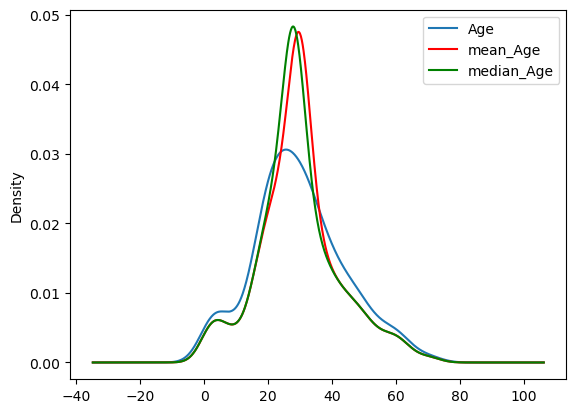

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['mean_Age'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['median_Age'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

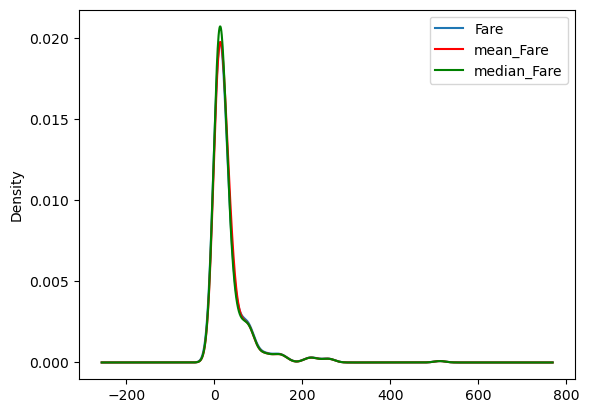

In [16]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)

X_train['mean_Fare'].plot(kind='kde',ax=ax,color='red')

X_train['median_Fare'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [17]:
X_train.cov()

,Age,Fare,Family,median_Age,mean_Age,median_Fare,mean_Fare
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858451,66.631558
Fare,70.719262,2448.197914,17.258917,59.661820,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.088278,-5.146106,16.476326,16.386748
median_Age,204.349513,59.661820,-5.088278,162.338530,161.812625,55.142638,56.613065
mean_Age,204.349513,55.603719,-5.146106,161.812625,161.812625,51.357677,52.761698
median_Fare,64.858451,2448.197914,16.476326,55.142638,51.357677,2340.098181,2324.533881
mean_Fare,66.631558,2448.197914,16.386748,56.613065,52.761698,2324.533881,2324.244026


In [18]:
X_train.corr()

,Age,Fare,Family,median_Age,mean_Age,median_Fare,mean_Fare
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087355,0.090109
Fare,0.092644,1.000000,0.208268,0.094361,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.241469,-0.244610,0.205942,0.205520
median_Age,1.000000,0.094361,-0.241469,1.000000,0.998379,0.089466,0.092165
mean_Age,1.000000,0.088069,-0.244610,0.998379,1.000000,0.083461,0.086034
median_Fare,0.087355,1.000000,0.205942,0.089466,0.083461,1.000000,0.996731
mean_Fare,0.090109,1.000000,0.205520,0.092165,0.086034,0.996731,1.000000


In [19]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

KeyError: "['Age_median', 'Age_mean'] not in index"

In [57]:
X_train=pd.DataFrame(X_train,columns=['Age','median_Age','mean_Age'])

<Axes: >

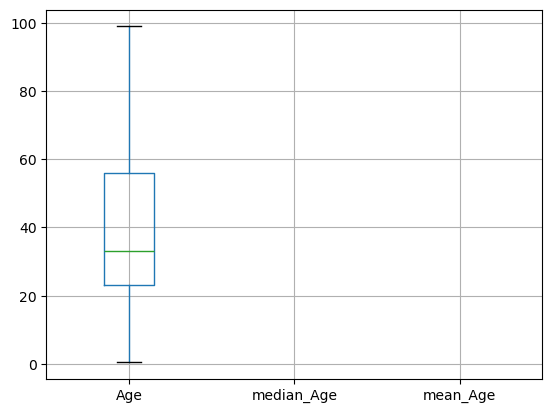

In [58]:
X_train[['Age', 'median_Age', 'mean_Age']].boxplot()

<h2></b>using sklearn fill missing value<b></h2>

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [42]:
imputer1=SimpleImputer(strategy='constant',fill_value=99)
imputer2=SimpleImputer(strategy='constant',fill_value=999)

In [45]:
trf=ColumnTransformer([
        ('imputer1',imputer1,['Age']),
        ('imputer2',imputer2,['Fare']),
],remainder='passthrough')


In [46]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [47]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [49]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [50]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [51]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))